# Training vs Validation Curves

**Section 1** — Per-model plots: for each model in `results/` (skipping `versioned/`), saves a `training_val_curves.png` with train vs validation loss, mAP, precision, and recall.

**Section 2** — Cross-model comparison: overlays all models' validation curves on shared axes so you can directly compare them. Saved to `results/comparison_curves.png`.

In [6]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import numpy as np

In [7]:
RESULTS_DIR      = Path("../results")
SKIP_DIRS        = {"versioned"}
PER_MODEL_FILE   = "training_val_curves.png"
COMPARISON_FILE  = RESULTS_DIR / "comparison_curves.png"

def find_model_dirs(root: Path, skip: set) -> list[Path]:
    """Return every directory under root (excluding skip subtrees) that contains results.csv."""
    found = []
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in skip]
        if "results.csv" in filenames:
            found.append(Path(dirpath))
    return sorted(found)

def make_label(model_dir: Path) -> str:
    """Turn a path like results/experiment/adamw into a short readable label."""
    parts = [p for p in model_dir.parts if p != str(RESULTS_DIR)]
    return " / ".join(p.replace("_", " ") for p in parts)

model_dirs = find_model_dirs(RESULTS_DIR, SKIP_DIRS)
print(f"Found {len(model_dirs)} model(s):")
for d in model_dirs:
    print(" ", d)

Found 7 model(s):
  ../results/baseline
  ../results/experiment/adamw
  ../results/experiment/adamw_imghigh
  ../results/experiment/cosine_lr_imghigh
  ../results/experiment/data_augmentation
  ../results/experiment/imgsize_high
  ../results/improvment_cycle


## Section 1 — Per-model: train vs validation

In [8]:
def plot_model(model_dir: Path) -> None:
    df = pd.read_csv(model_dir / "results.csv")
    df.columns = df.columns.str.strip()
    epochs = df["epoch"]
    title  = make_label(model_dir).title()

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── Row 0: loss components ──────────────────────────────────────────────
    for col, (panel_title, train_col, val_col) in enumerate([
        ("Box Loss", "train/box_loss", "val/box_loss"),
        ("Cls Loss", "train/cls_loss", "val/cls_loss"),
        ("DFL Loss", "train/dfl_loss", "val/dfl_loss"),
    ]):
        ax = fig.add_subplot(gs[0, col])
        ax.plot(epochs, df[train_col], label="Train",      color="steelblue", linewidth=1.8)
        ax.plot(epochs, df[val_col],   label="Validation", color="tomato",    linewidth=1.8)
        ax.set_title(panel_title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # ── Row 1: mAP50 ────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, df["metrics/mAP50(B)"], color="mediumseagreen", linewidth=1.8)
    ax.set_title("mAP@50")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    # ── Row 1: mAP50-95 ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, df["metrics/mAP50-95(B)"], color="darkorchid", linewidth=1.8)
    ax.set_title("mAP@50-95")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    # ── Row 1: Precision & Recall ───────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    ax.plot(epochs, df["metrics/precision(B)"], label="Precision", color="goldenrod",       linewidth=1.8)
    ax.plot(epochs, df["metrics/recall(B)"],    label="Recall",    color="cornflowerblue",  linewidth=1.8, linestyle="--")
    ax.set_title("Precision & Recall")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    out = model_dir / PER_MODEL_FILE
    fig.savefig(out, bbox_inches="tight", dpi=150)
    plt.close(fig)
    print(f"  Saved → {out}")

In [9]:
for model_dir in model_dirs:
    print(f"Processing: {model_dir}")
    plot_model(model_dir)

print("\nSection 1 done.")

Processing: ../results/baseline
  Saved → ../results/baseline/training_val_curves.png
Processing: ../results/experiment/adamw
  Saved → ../results/experiment/adamw/training_val_curves.png
Processing: ../results/experiment/adamw_imghigh
  Saved → ../results/experiment/adamw_imghigh/training_val_curves.png
Processing: ../results/experiment/cosine_lr_imghigh
  Saved → ../results/experiment/cosine_lr_imghigh/training_val_curves.png
Processing: ../results/experiment/data_augmentation
  Saved → ../results/experiment/data_augmentation/training_val_curves.png
Processing: ../results/experiment/imgsize_high
  Saved → ../results/experiment/imgsize_high/training_val_curves.png
Processing: ../results/improvment_cycle
  Saved → ../results/improvment_cycle/training_val_curves.png

Section 1 done.


## Section 2 — Cross-model comparison

Each subplot shows one metric with all models overlaid so you can compare their validation curves directly.

Metrics compared:
- Val Box / Cls / DFL loss
- mAP@50 and mAP@50-95
- Precision and Recall

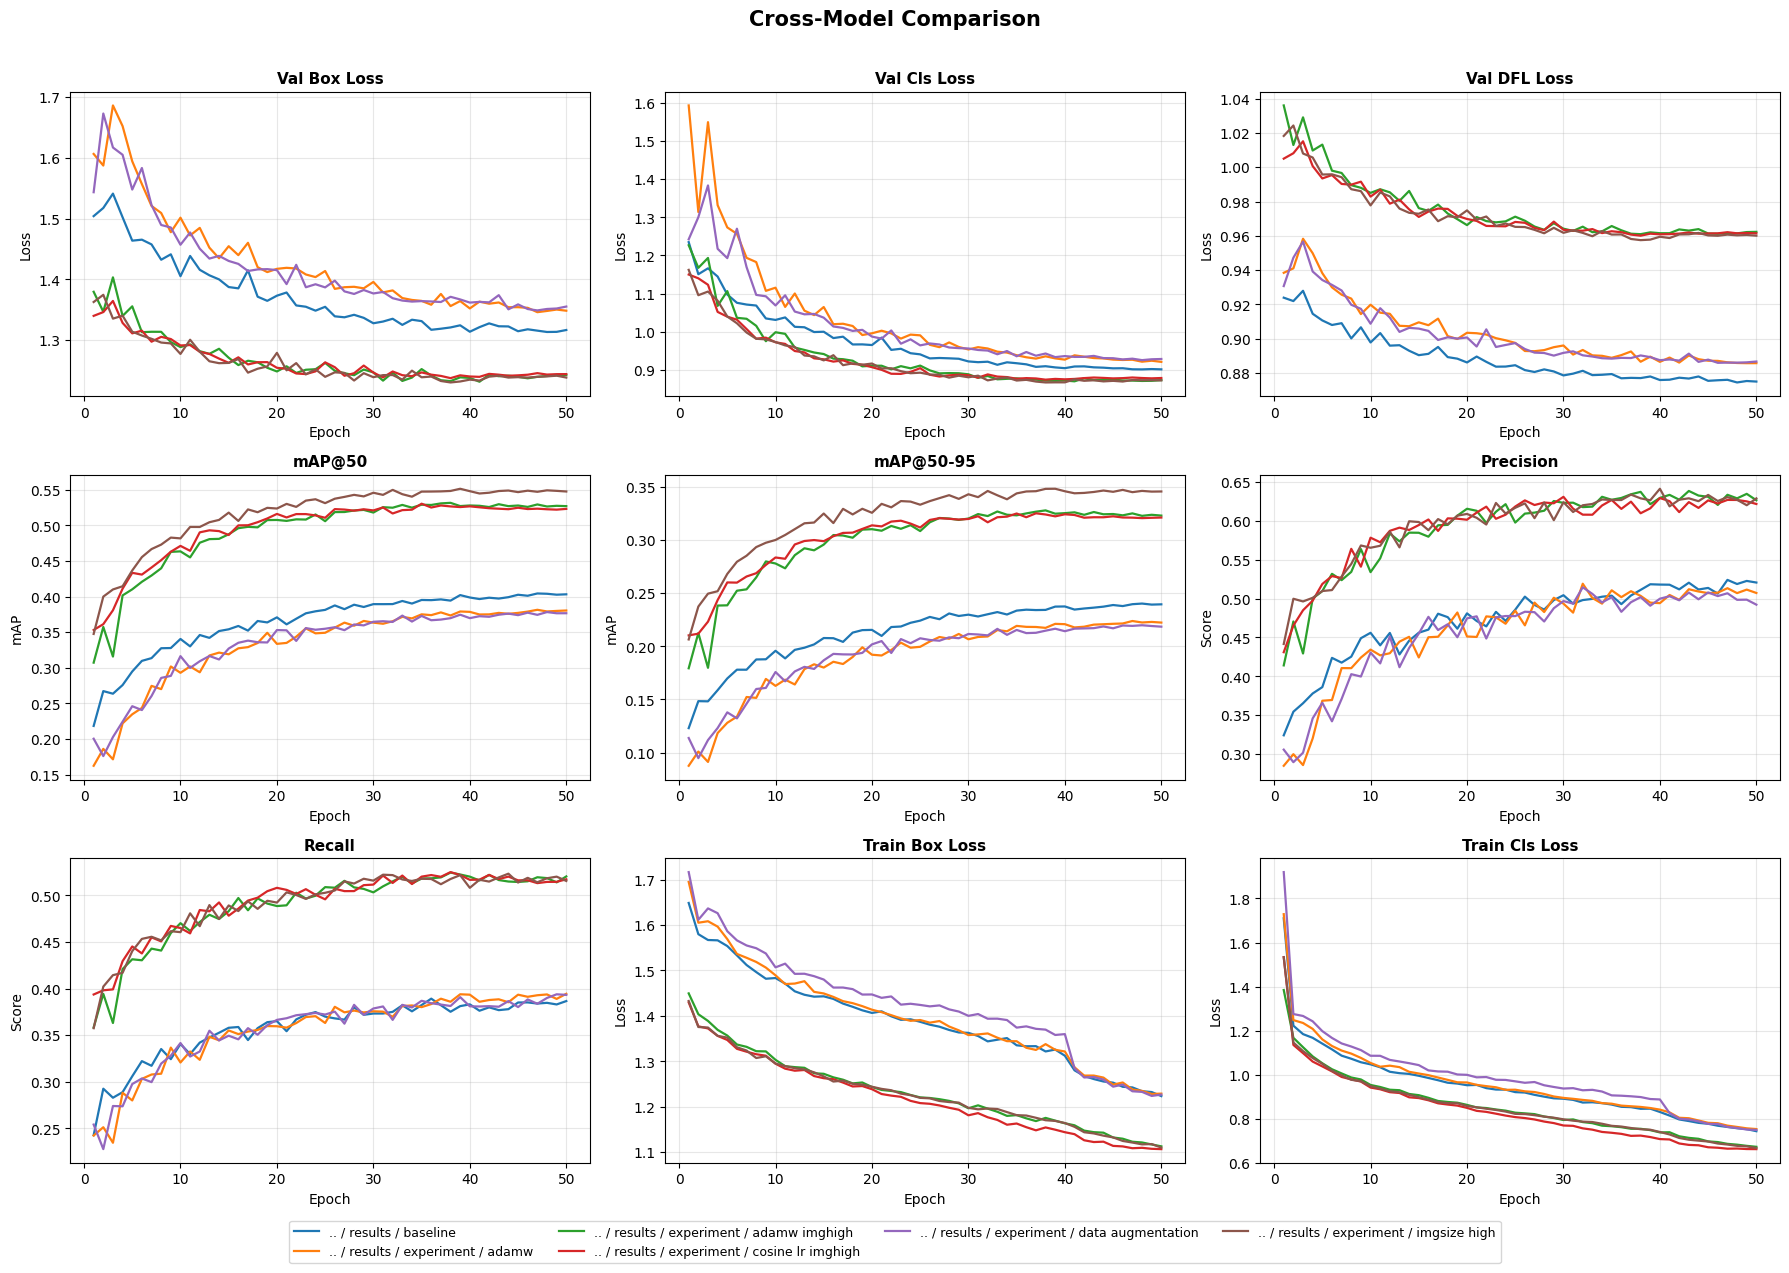


Comparison plot saved → ../results/comparison_curves.png


In [10]:
# Load all dataframes once (exclude improvement cycle from comparison)
COMPARISON_SKIP = {"improvment_cycle"}

datasets: list[tuple[str, pd.DataFrame]] = []
for model_dir in model_dirs:
    if any(part in COMPARISON_SKIP for part in model_dir.parts):
        continue
    df = pd.read_csv(model_dir / "results.csv")
    df.columns = df.columns.str.strip()
    datasets.append((make_label(model_dir), df))

# Assign a distinct color to each model (tab10 has 10 hand-picked distinct colors)
colors = [cm.tab10(i / 10.0) for i in range(len(datasets))]

COMPARISON_PANELS = [
    # (subplot title,        column name,               y-axis label)
    ("Val Box Loss",          "val/box_loss",            "Loss"),
    ("Val Cls Loss",          "val/cls_loss",            "Loss"),
    ("Val DFL Loss",          "val/dfl_loss",            "Loss"),
    ("mAP@50",                "metrics/mAP50(B)",        "mAP"),
    ("mAP@50-95",             "metrics/mAP50-95(B)",     "mAP"),
    ("Precision",             "metrics/precision(B)",    "Score"),
    ("Recall",                "metrics/recall(B)",       "Score"),
    ("Train Box Loss",        "train/box_loss",          "Loss"),
    ("Train Cls Loss",        "train/cls_loss",          "Loss"),
]

N_COLS = 3
N_ROWS = int(np.ceil(len(COMPARISON_PANELS) / N_COLS))

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * 4))
axes = axes.flatten()

for ax_idx, (panel_title, col_name, ylabel) in enumerate(COMPARISON_PANELS):
    ax = axes[ax_idx]
    for (label, df), color in zip(datasets, colors):
        ax.plot(df["epoch"], df[col_name], label=label, color=color, linewidth=1.6)
    ax.set_title(panel_title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for ax_idx in range(len(COMPARISON_PANELS), len(axes)):
    axes[ax_idx].set_visible(False)

# Shared legend outside the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=min(len(datasets), 4),
    bbox_to_anchor=(0.5, -0.04),
    fontsize=9,
    frameon=True,
)

fig.suptitle("Cross-Model Comparison", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(COMPARISON_FILE, bbox_inches="tight", dpi=150)
plt.show()
print(f"\nComparison plot saved → {COMPARISON_FILE}")